In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
ndimage = pyimport("scipy.ndimage") 

PyObject <module 'scipy.ndimage' from '/home/gridsan/aligho/.local/lib/python3.8/site-packages/scipy/ndimage/__init__.py'>

In [4]:
Energies = zeros(20, 20)
for i in 1:20
    for j in 1:20
        try
        Energies[i, j] = list_energy("Moire-$i-$j.out")
        catch e
            println(e)
        end
    end
end

In [95]:
Energies_single = zeros(20, 20)
for i in 1:20
    for j in 1:20
        try
        Energies_single[i, j] =
        energy = list_energy("../single_atom_stability/Moire-$i-$j.out")
        if (energy==0)
            energy = list_energy("../single_atom_stability/Moire-$j-$i.out")
        end
        Energies_single[i, j] = energy

        catch e
            println(e)
        end
    end
end

In [98]:
no_zeros = filter(e->!iszero(e), Energies_single);

In [99]:
Energies_single2 = replace(Energies_single, 0 => maximum(no_zeros))

20×20 Matrix{Float64}:
 -4632.37  -4632.38  -4632.41  -4632.47  …  -4628.29  -4628.29  -4628.29
 -4632.38  -4632.38  -4632.4   -4632.45     -4628.29  -4628.29  -4628.29
 -4632.41  -4632.4   -4632.41  -4632.45     -4628.29  -4628.29  -4628.29
 -4632.47  -4632.45  -4632.45  -4632.47     -4630.43  -4628.29  -4628.29
 -4632.55  -4632.52  -4632.51  -4632.52     -4631.82  -4630.66  -4628.33
 -4632.66  -4632.61  -4632.59  -4632.59  …  -4632.55  -4632.01  -4631.19
 -4632.79  -4632.73  -4632.69  -4632.68     -4632.97  -4632.7   -4632.3
 -4632.92  -4632.86  -4632.82  -4632.79     -4633.17  -4633.06  -4632.87
 -4632.99  -4632.98  -4632.95  -4632.92     -4633.22  -4633.2   -4633.14
 -4632.95  -4632.99  -4633.03  -4633.04     -4633.22  -4633.23  -4633.23
 -4632.98  -4632.97  -4632.99  -4633.08  …  -4633.17  -4633.2   -4633.23
 -4632.97  -4633.0   -4633.0   -4633.02     -4632.97  -4633.06  -4633.14
 -4632.83  -4632.94  -4633.01  -4633.05     -4632.55  -4632.7   -4632.87
 -4632.45  -4632.7   -4632.89

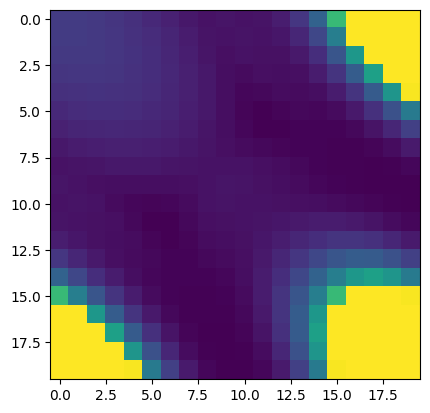

PyObject <matplotlib.image.AxesImage object at 0x7f6091616fa0>

In [100]:
imshow(Energies_single2)

In [102]:
zEnergies_stability=zscore(Energies_single2+Energies);

In [21]:
v1, v2, v3 = loadlattice("Moire-1-1.out");

In [31]:
det(hcat(v1, v2, v3))/7/sqrt(sum(v3.*v3))/(1.44*1.4*3*sqrt(3)/2)

1.006043669360986

In [23]:
sum(v1 .* v2)/sum(v1.*v1)

-0.5000013378236597

In [47]:
lattice_to_cartesian = 
[ -11.8187  2.36374;  4.09412  -12.2824 ] .*235/20/sqrt((-11.818700)^2+4.09412^2)

2×2 Matrix{Float64}:
 -11.1027     2.22054
   3.84609  -11.5383

In [157]:
superlattice_to_cartesian = 
[ -11.8187  2.36374;  4.09412  -12.2824 ] .*235/20/sqrt((-11.818700)^2+4.09412^2)

2×2 Matrix{Float64}:
 -11.1027     2.22054
   3.84609  -11.5383

In [158]:
cartesian_to_lattice = inv(lattice_to_cartesian)

2×2 Matrix{Float64}:
 -0.0965016  -0.0185717
 -0.0321671  -0.0928583

In [159]:
cartesian_to_superlattice = inv(superlattice_to_cartesian)

2×2 Matrix{Float64}:
 -0.0965016  -0.0185717
 -0.0321671  -0.0928583

In [64]:
zEnergies = zscore(Energies);

In [160]:
function returnE(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_lattice*x)) 
    i, j = rem.([i, j], 20)
    i < 0 && (i = i+20)
    j < 0 && (j = j+20)
    return (zEnergies[i+1, j+1])
end

returnE (generic function with 1 method)

In [206]:
function returnE_stability(x::Vector{<:Real})
    i, j = Int.(round.(cartesian_to_superlattice*x))
    i, j = rem.([i, j], 40)
    i < 0 && (i = i+40)
    j < 0 && (j = j+40)
   #(i==0 && j==0) &&  println(i, " ", j)

    #=(i != 9  && j != 9) && return (zEnergies_stability[i+1, j+1])
    (i == 9  && j != 9) && return (zEnergies_stability[9, j+1])
    (i != 9  && j == 9) && return (zEnergies_stability[i+1, 9])
    (i == 9  && j == 9) && return (zEnergies_stability[9, 9])
=#
    if (i < 20) && (j < 20)
        return zEnergies_stability[i+1, j+1]
    else
        return 0
    end
end

returnE_stability (generic function with 1 method)

In [197]:
N=400
EnergyArray = zeros(N, N)
for i in 1:N
    for j in 1:N
        r=[i, j]-[115, -27]
        EnergyArray[i, j] = returnE(r)
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

In [257]:
N=400
EnergyArrayStability = zeros(N, N)
for i in 1:N
    for j in 1:N
        r=[i, j]-round.([115, -27]/2)-[-210, 290]
        EnergyArrayStability[i, j] = returnE_stability(r)
        #EnergyArray[i, j]  = log(returnE([i, j]) - minimum(Energies) .+ 0.1)
    end
end

In [170]:
Moire_Fig = imread("Moire.jpg");

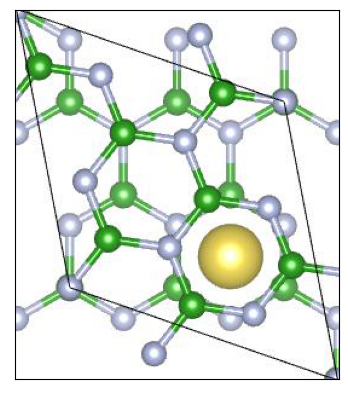

(Any[], Any[])

In [171]:
imshow(Moire_Fig, alpha=1, cmap="hot")
ylim(377, 71)
xlim(112, 380)
xticks(Float64[])
yticks(Float64[])

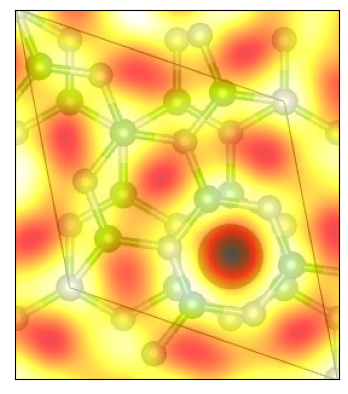

(Any[], Any[])

In [199]:
imshow(Moire_Fig, alpha=1, cmap="hot")
img = ndimage.gaussian_filter(np.rot90(EnergyArray), sigma=10)
imshow(img, cmap="hot", alpha=0.7)

ylim(377, 71)
xlim(112, 380)
xticks(Float64[])
yticks(Float64[])
#imshow(np.rot90(EnergyArray), interpolation="gaussian", cmap="hot", alpha=0.1)

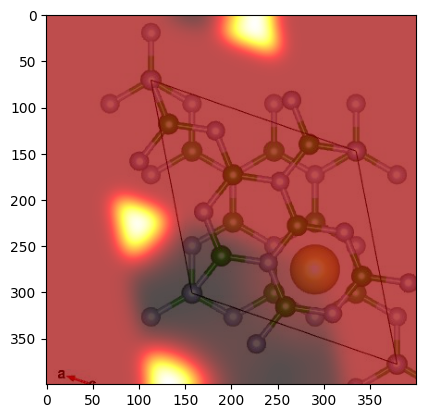

PyObject <matplotlib.image.AxesImage object at 0x7f608dc9eeb0>

In [259]:
#img = ndimage.gaussian_filter(np.rot90(EnergyArrayStability), sigma=10)
imshow(Moire_Fig, alpha=1, cmap="hot")

img = ndimage.gaussian_filter(EnergyArrayStability, sigma=10)
imshow(np.rot90(img), cmap="hot", alpha=0.7)
#ylim(377, 71)
#xlim(112, 380)
#xticks(Float64[])
#yticks(Float64[])


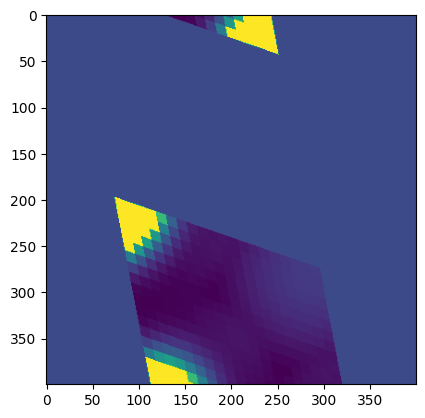

PyObject <matplotlib.image.AxesImage object at 0x7f608dbe0a90>

In [262]:
imshow(np.rot90(EnergyArrayStability))

In [289]:
E = Energies+Energies_single

20×20 Matrix{Float64}:
 -10682.1   -10682.1   -10682.1   …   -6049.72   -6049.72   -6049.73
 -10682.1   -10682.1   -10682.1       -6049.72   -6049.72   -6049.72
 -10682.1   -10682.1   -10682.1       -6049.72   -6049.72   -6049.72
 -10682.2   -10682.2   -10682.2      -10680.2    -6049.72   -6049.72
 -10682.3   -10682.2   -10682.2      -10681.5   -10680.4   -10678.1
 -10682.4   -10682.3   -10682.3   …  -10682.3   -10681.7   -10680.9
 -10682.5   -10682.4   -10682.4      -10682.7   -10682.4   -10682.0
 -10682.6   -10682.6   -10682.5      -10682.9   -10682.8   -10682.6
 -10682.7   -10682.7   -10682.7      -10682.9   -10682.9   -10682.9
 -10682.7   -10682.7   -10682.8      -10682.9   -10682.9   -10682.9
 -10682.7   -10682.7   -10682.7   …  -10682.9   -10682.9   -10682.9
 -10682.7   -10682.7   -10682.7      -10682.7   -10682.8   -10682.9
 -10682.5   -10682.7   -10682.7      -10682.3   -10682.4   -10682.6
 -10682.2   -10682.4   -10682.6      -10681.5   -10681.7   -10682.0
 -10681.4   -10681.9 

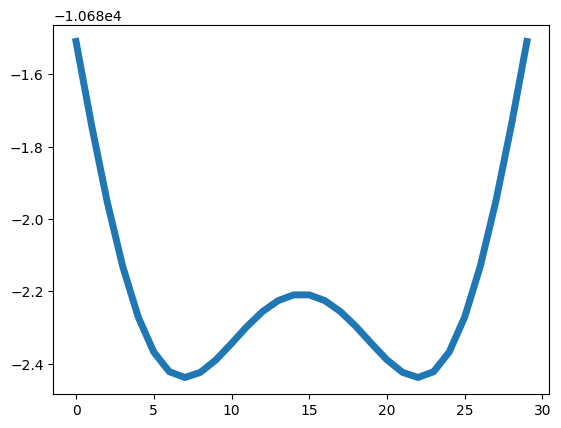

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f608d60fac0>

In [290]:
plot(smooth(E[1, np.ndarray.flatten([collect(15:-1:1)... collect(1:15)... ])], win_len=20), linewidth=5)

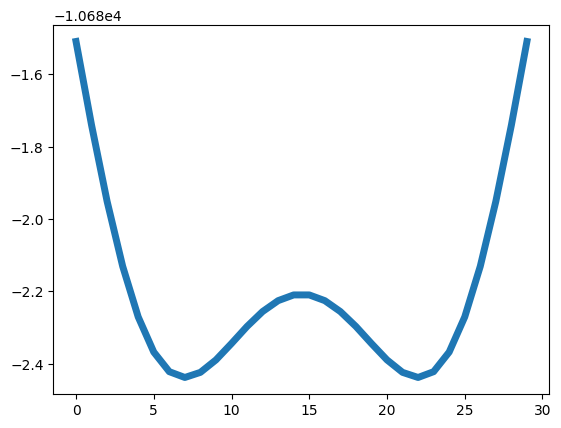

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f608d5e6c70>

In [291]:
plot(smooth(E[np.ndarray.flatten([collect(15:-1:1)... collect(1:15)... ]), 1], win_len=20), linewidth=5)
